
<div style="text-align: center; background-color: lightblue; padding: 15px;">
    <p style="text-align: center;">بسم الله، والحمد لله، والصلاة والسلام على رسول الله وعلى آله وصحبه</p>
</div>

# I- NECESSARY TOOLS

In [1]:
from me_r_sy.ingestion.grib import get_grib , get_var
from me_r_sy.visualization.plots import plot_it , plot_wind
import geopandas as gpd
import numpy as np
import yaml
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [2]:
# read the config file
config_file = "/home/muhammed/METEO-REPORTING-SYSTEM/ME_R_SY/config/config.yml"
with open(config_file , "r") as f :
    config = yaml.safe_load(f)
    

In [3]:
cmap_dict = {
    "2t" : "RdYlBu_r" , 
    "tp"  : "GnBu" , 
    "msl" : "viridis" , 
    "w"   : "YlOrRd"
}

In [4]:
year       = config["date"]["year"]
month      = config["date"]["month"]
input_dir  = config["data"]["input"] 
output_dir = config["data"]["output"] 
shp_path   = config["data"]["shapefile"]
year       = config["date"]["year"]
month      = config["date"]["month"]

# II- READ DATA

In [5]:
# read the shapefile
shp = gpd.read_file(shp_path)
ds  = get_grib(input_dir , year , month)
# get vars
t   = get_var(ds , "t2m")
u   = get_var(ds , "u10")
v   = get_var(ds , "v10")
tp  = get_var(ds , "tp")
w   = np.sqrt(u**2 + v**2) 
p   = get_var(ds , "msl") 
# get monthly vars
u_m  = u.resample(time = "ME").mean().squeeze()
v_m  = v.resample(time = "ME").mean().squeeze()
w_m  = np.sqrt(u_m**2 + v_m**2)
p_m  = p.resample(time = "ME").mean().squeeze()
t_m  = t.resample(time = "ME").mean().squeeze()
tp_m = tp[:,0,:,:].resample(time = "ME").sum().sum(dim = "time")

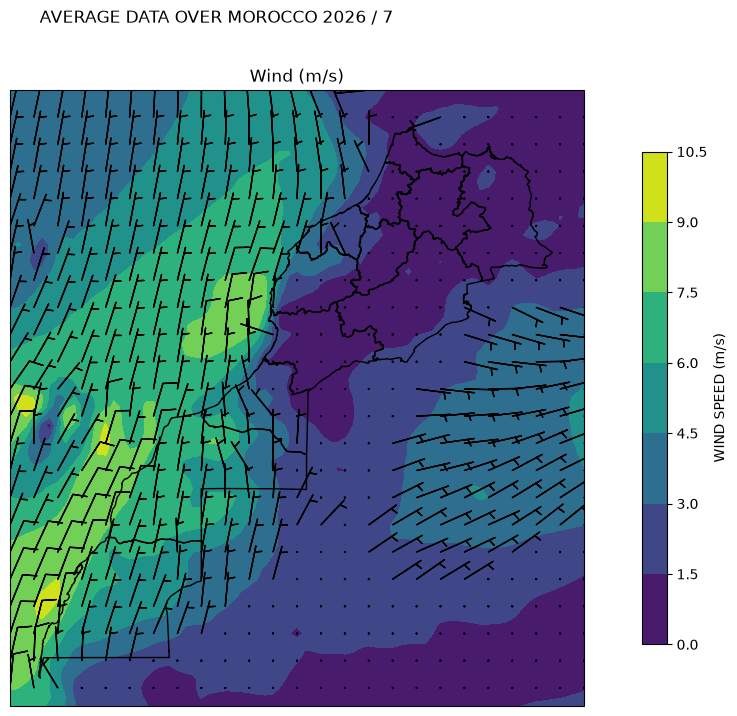

In [6]:
fig , ax = plt.subplots(figsize = (15,8) ,ncols =  1 , nrows =  1 , subplot_kw = {"projection" : ccrs.PlateCarree()})
# plots.plot_it(fig , ax , p_m , shp , year , month)
plot_wind(fig , ax , u_m , v_m , w_m , shp , year , month)

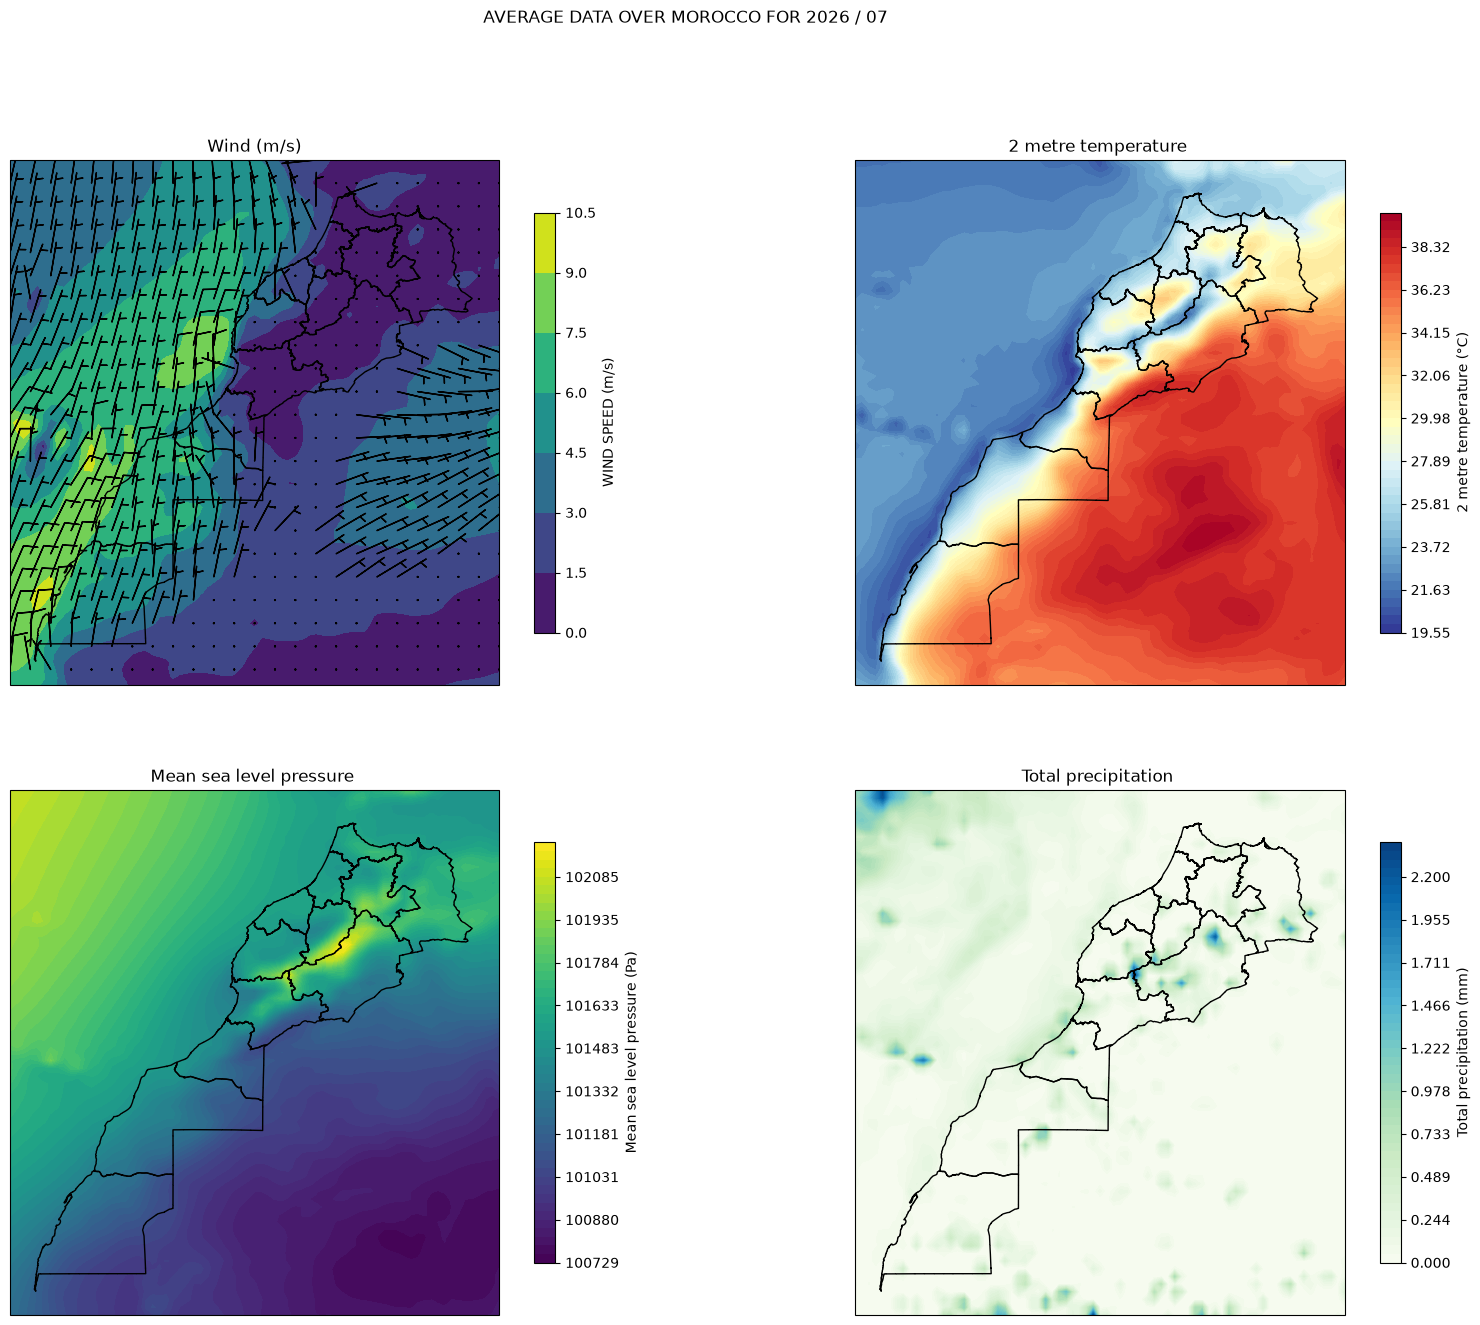

In [7]:
fig , ax = plt.subplots(figsize = (20,15) , ncols = 2 , nrows = 2 , subplot_kw = {"projection" : ccrs.PlateCarree()})
ax = ax.flatten()
plot_wind(fig , ax[0] , u_m , v_m , w_m , shp , year , month)
for i , var in enumerate([t_m , p_m , tp_m]) : 
    plot_it(fig , ax[i+1] , var , shp , year , month ) 
    
